# Clinical Trials Analysis — EDA & Tie-out Validation

**Dataset:** 137,556 clinical trials | 2010-2024 | Phases I-IV | ClinicalTrials.gov API v2

**Purpose:** Independent validation of Power BI dashboard metrics via direct DuckDB queries.
Each section computes numbers independently and flags discrepancies vs. dashboard.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

CHARTS = Path("/home/adrian/projects/clinical_trials_analysis/outputs/charts")
CHARTS.mkdir(parents=True, exist_ok=True)
DB_PATH = Path("/home/adrian/projects/clinical_trials_analysis/data/dwh_dev.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"Connected: {DB_PATH}")

Connected: /home/adrian/projects/clinical_trials_analysis/data/dwh_dev.duckdb


## 1. Overview

In [2]:
overview = con.execute("""
    SELECT
        COUNT(*) AS total_trials,
        ROUND(AVG(enrollment_count), 0) AS avg_enrollment,
        ROUND(AVG(CASE WHEN s.is_completed THEN duration_days END), 0) AS avg_duration_days
    FROM main.fct_clinical_trials f
    JOIN main.dim_status s ON f.status_id = s.status_id
""").df()
overview

,total_trials,avg_enrollment,avg_duration_days
0,137556,305.0,839.0


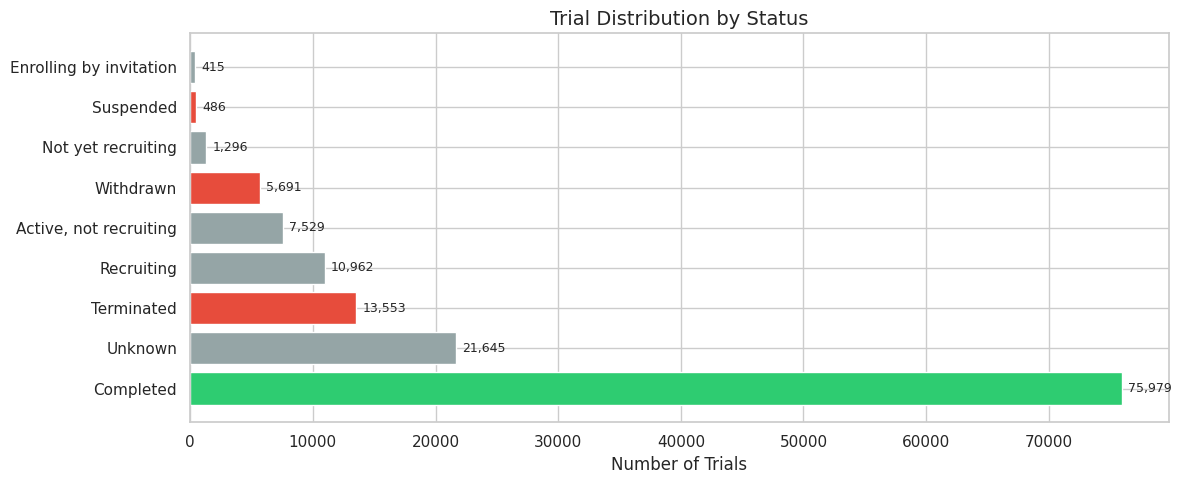

In [3]:
df_status = con.execute("""
    SELECT s.status_label, COUNT(*) AS n_trials
    FROM main.fct_clinical_trials f
    JOIN main.dim_status s ON f.status_id = s.status_id
    GROUP BY s.status_label ORDER BY n_trials DESC
""").df()

colors = ['#2ecc71' if s == 'Completed' else '#e74c3c' if s in ('Terminated','Withdrawn','Suspended') else '#95a5a6' for s in df_status['status_label']]
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(df_status['status_label'], df_status['n_trials'], color=colors)
ax.set_title('Trial Distribution by Status', fontsize=14)
ax.set_xlabel('Number of Trials')
for i, v in enumerate(df_status['n_trials']):
    ax.text(v + 500, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
fig.savefig(CHARTS / "01_status_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### Tie-out: Overview
| KPI | DuckDB Value | Dashboard | Match? |
|---|---|---|---|
| Total Trials | *computed* | *from dashboard* | |
| Avg Enrollment | *computed* | *from dashboard* | |
| Avg Duration (days) | *computed* | *from dashboard* | |

## 2. Completion/Abandonment Rate by Phase

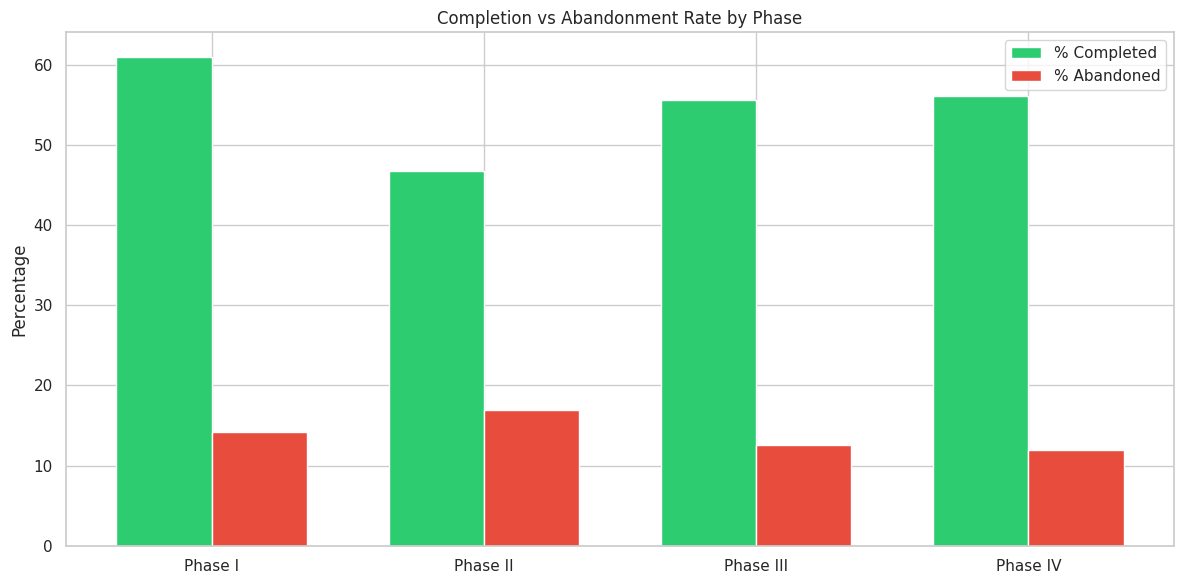

,phase_label,total,completed,abandoned,c_pct,a_pct
0,Phase I,44308,27028.0,6280.0,61.0,14.2
1,Phase II,56817,26602.0,9685.0,46.8,17.0
2,Phase III,29674,16507.0,3749.0,55.6,12.6
3,Phase IV,23259,13050.0,2796.0,56.1,12.0


In [4]:
df_phase = con.execute("""
    SELECT p.phase_label, COUNT(*) AS total,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS c_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS a_pct
    FROM main.brg_trial_phase bp
    JOIN main.dim_phase p ON bp.phase_id = p.phase_id
    JOIN main.fct_clinical_trials f ON bp.nct_id = f.nct_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    WHERE p.is_main_phase
    GROUP BY p.phase_label ORDER BY MIN(p.phase_id)
""").df()

x = range(len(df_phase))
w = 0.35
fig, ax = plt.subplots()
ax.bar([i - w/2 for i in x], df_phase['c_pct'], w, color='#2ecc71', label='% Completed')
ax.bar([i + w/2 for i in x], df_phase['a_pct'], w, color='#e74c3c', label='% Abandoned')
ax.set_xticks(x)
ax.set_xticklabels(df_phase['phase_label'])
ax.set_title('Completion vs Abandonment Rate by Phase')
ax.set_ylabel('Percentage')
ax.legend()
plt.tight_layout()
fig.savefig(CHARTS / "02_completion_by_phase.png", dpi=150, bbox_inches='tight')
plt.show()
df_phase

## 3. Completion/Abandonment Rate by Sponsor

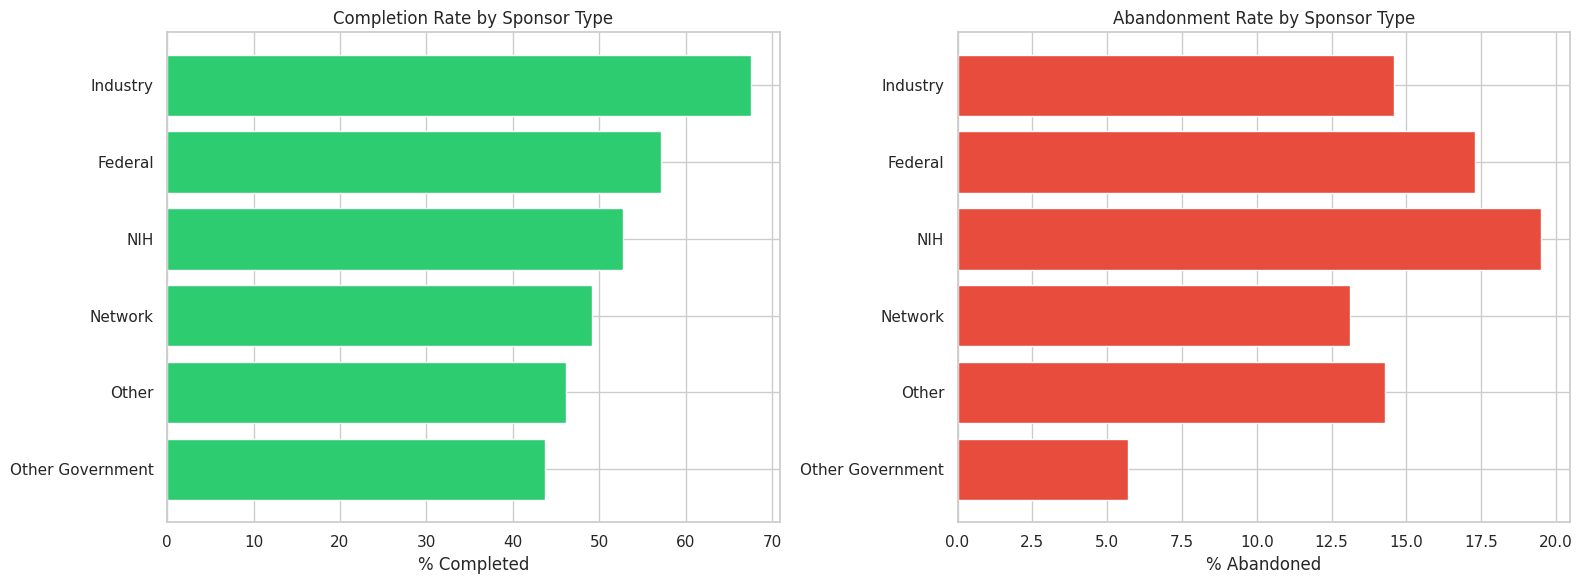

,sponsor_class_label,total,completed,abandoned,c_pct,a_pct
0,Other,72984,33691.0,10416.0,46.2,14.3
1,Industry,57496,38798.0,8396.0,67.5,14.6
2,Other Government,2607,1139.0,149.0,43.7,5.7
3,NIH,2412,1270.0,471.0,52.7,19.5
4,Network,1157,568.0,152.0,49.1,13.1
5,Federal,693,396.0,120.0,57.1,17.3


In [5]:
df_sponsor = con.execute("""
    SELECT sp.sponsor_class_label, COUNT(*) AS total,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS c_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS a_pct
    FROM main.fct_clinical_trials f
    JOIN main.dim_sponsor sp ON f.sponsor_id = sp.sponsor_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    WHERE sp.lead_sponsor_class IN ('INDUSTRY', 'NIH', 'OTHER', 'OTHER_GOV', 'NETWORK', 'FED')
    GROUP BY sp.sponsor_class_label ORDER BY total DESC
""").df()

sp = df_sponsor.sort_values('c_pct', ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.barh(sp['sponsor_class_label'], sp['c_pct'], color='#2ecc71')
ax1.set_title('Completion Rate by Sponsor Type')
ax1.set_xlabel('% Completed')
ax2.barh(sp['sponsor_class_label'], sp['a_pct'], color='#e74c3c')
ax2.set_title('Abandonment Rate by Sponsor Type')
ax2.set_xlabel('% Abandoned')
plt.tight_layout()
fig.savefig(CHARTS / "03_completion_by_sponsor.png", dpi=150, bbox_inches='tight')
plt.show()
df_sponsor

## 4. Completion/Abandonment Rate by Intervention Type

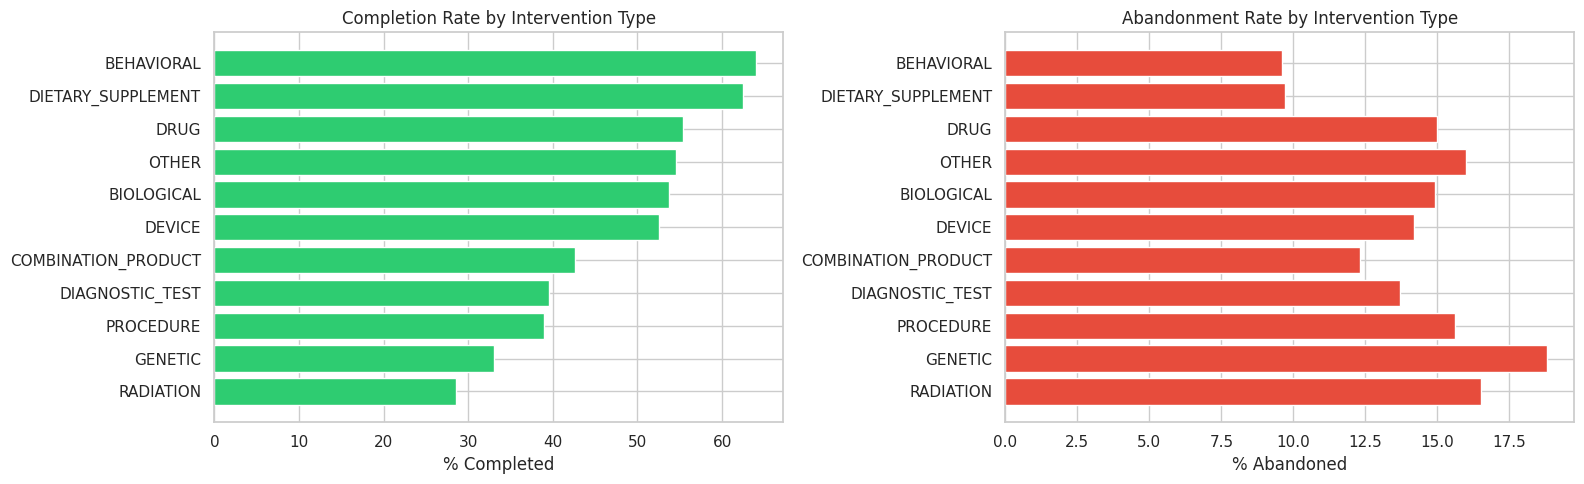

,intervention_name,total,completed,abandoned,c_pct,a_pct
0,DRUG,111575,61807.0,16716.0,55.4,15.0
1,BIOLOGICAL,16488,8853.0,2461.0,53.7,14.9
2,OTHER,13184,7199.0,2105.0,54.6,16.0
3,PROCEDURE,6978,2720.0,1092.0,39.0,15.6
4,DEVICE,5771,3035.0,820.0,52.6,14.2
5,RADIATION,3778,1082.0,625.0,28.6,16.5
6,BEHAVIORAL,2578,1650.0,248.0,64.0,9.6
7,DIETARY_SUPPLEMENT,2431,1519.0,237.0,62.5,9.7
8,COMBINATION_PRODUCT,1535,654.0,189.0,42.6,12.3
9,DIAGNOSTIC_TEST,564,223.0,77.0,39.5,13.7


In [6]:
df_interv = con.execute("""
    SELECT i.intervention_name, COUNT(*) AS total,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS c_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS a_pct
    FROM main.brg_trial_intervention bi
    JOIN main.dim_intervention_type i ON bi.intervention_type_id = i.intervention_type_id
    JOIN main.fct_clinical_trials f ON bi.nct_id = f.nct_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    GROUP BY i.intervention_name ORDER BY total DESC
""").df()

iv = df_interv.sort_values('c_pct', ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.barh(iv['intervention_name'], iv['c_pct'], color='#2ecc71')
ax1.set_title('Completion Rate by Intervention Type')
ax1.set_xlabel('% Completed')
ax2.barh(iv['intervention_name'], iv['a_pct'], color='#e74c3c')
ax2.set_title('Abandonment Rate by Intervention Type')
ax2.set_xlabel('% Abandoned')
plt.tight_layout()
fig.savefig(CHARTS / "04_completion_by_intervention.png", dpi=150, bbox_inches='tight')
plt.show()
df_interv

## 5. Completion/Abandonment Rate by Enrollment Band

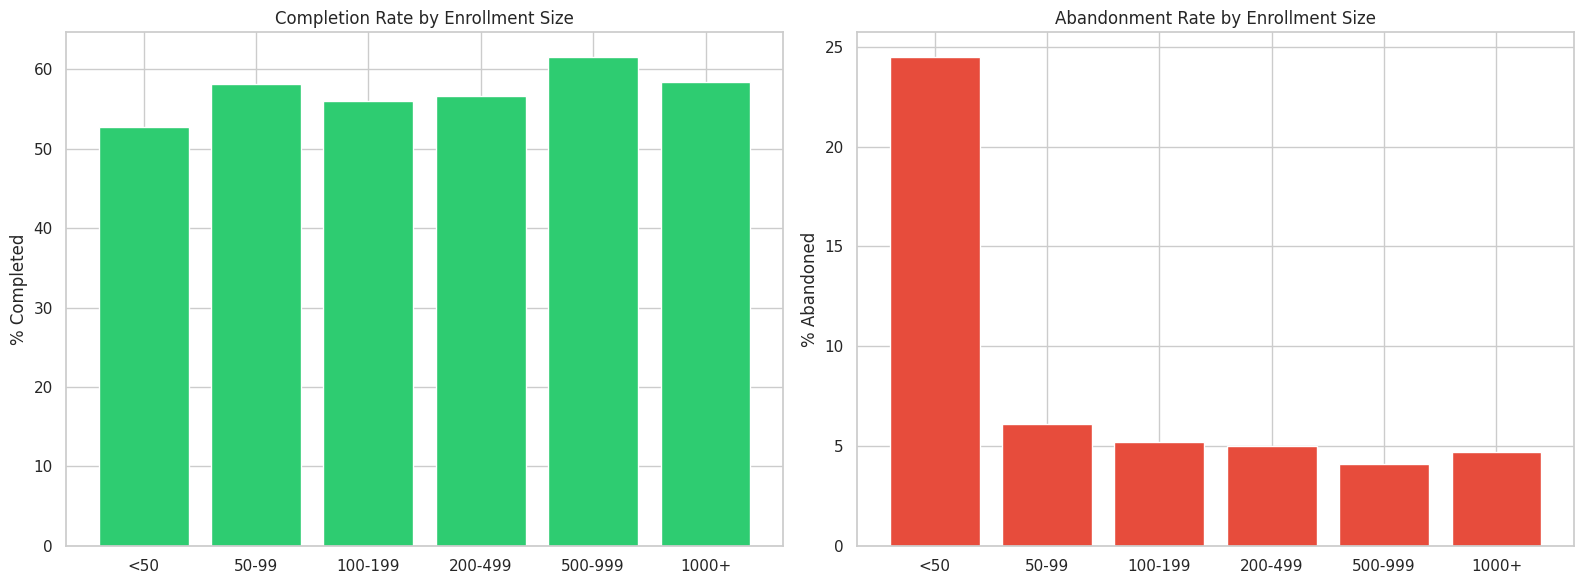

,band,total,completed,abandoned,c_pct,a_pct
0,<50,64378,33900.0,15787.0,52.7,24.5
1,50-99,27302,15884.0,1656.0,58.2,6.1
2,100-199,20067,11247.0,1051.0,56.0,5.2
3,200-499,16347,9245.0,821.0,56.6,5.0
4,500-999,5580,3440.0,230.0,61.6,4.1
5,1000+,3808,2224.0,179.0,58.4,4.7


In [7]:
df_enroll = con.execute("""
    SELECT
        CASE WHEN enrollment_count < 50 THEN '<50'
             WHEN enrollment_count < 100 THEN '50-99'
             WHEN enrollment_count < 200 THEN '100-199'
             WHEN enrollment_count < 500 THEN '200-499'
             WHEN enrollment_count < 1000 THEN '500-999'
             ELSE '1000+' END AS band,
        COUNT(*) AS total,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS c_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS a_pct
    FROM main.fct_clinical_trials f
    JOIN main.dim_status s ON f.status_id = s.status_id
    WHERE enrollment_count IS NOT NULL
    GROUP BY band ORDER BY MIN(enrollment_count)
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.bar(df_enroll['band'], df_enroll['c_pct'], color='#2ecc71')
ax1.set_title('Completion Rate by Enrollment Size')
ax1.set_ylabel('% Completed')
ax2.bar(df_enroll['band'], df_enroll['a_pct'], color='#e74c3c')
ax2.set_title('Abandonment Rate by Enrollment Size')
ax2.set_ylabel('% Abandoned')
plt.tight_layout()
fig.savefig(CHARTS / "05_completion_by_enrollment.png", dpi=150, bbox_inches='tight')
plt.show()
df_enroll

## 6. Completion/Abandonment Rate by Clinical Condition (Top 5, excl. 'healthy')

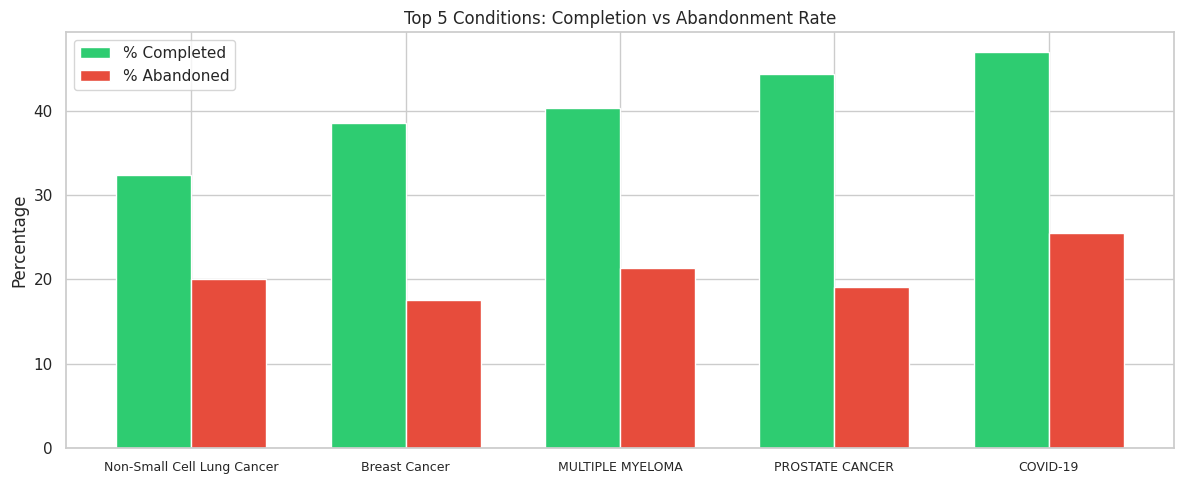

,condition,total,completed,abandoned,c_pct,a_pct
0,Breast Cancer,1976,762.0,347.0,38.6,17.6
1,COVID-19,1951,917.0,497.0,47.0,25.5
2,Non-Small Cell Lung Cancer,1104,358.0,222.0,32.4,20.1
3,MULTIPLE MYELOMA,1103,446.0,235.0,40.4,21.3
4,PROSTATE CANCER,1100,488.0,210.0,44.4,19.1


In [8]:
df_cond = con.execute("""
    SELECT c.condition_name_normalized AS condition, COUNT(*) AS total,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS c_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS a_pct
    FROM main.brg_trial_condition bc
    JOIN main.dim_condition c ON bc.condition_id = c.condition_id
    JOIN main.fct_clinical_trials f ON bc.nct_id = f.nct_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    WHERE LOWER(c.condition_name_normalized) NOT LIKE '%healthy%'
    GROUP BY c.condition_name_normalized
    HAVING COUNT(*) >= 1000
    ORDER BY total DESC LIMIT 5
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
cd = df_cond.sort_values('c_pct', ascending=True)
x = range(len(cd))
w = 0.35
ax.bar([i - w/2 for i in x], cd['c_pct'], w, color='#2ecc71', label='% Completed')
ax.bar([i + w/2 for i in x], cd['a_pct'], w, color='#e74c3c', label='% Abandoned')
ax.set_xticks(x)
ax.set_xticklabels(cd['condition'], fontsize=9)
ax.set_title('Top 5 Conditions: Completion vs Abandonment Rate')
ax.set_ylabel('Percentage')
ax.legend()
plt.tight_layout()
fig.savefig(CHARTS / "06_completion_by_condition.png", dpi=150, bbox_inches='tight')
plt.show()
df_cond

## 7. Completion/Abandonment Rate by Country (Top 10)

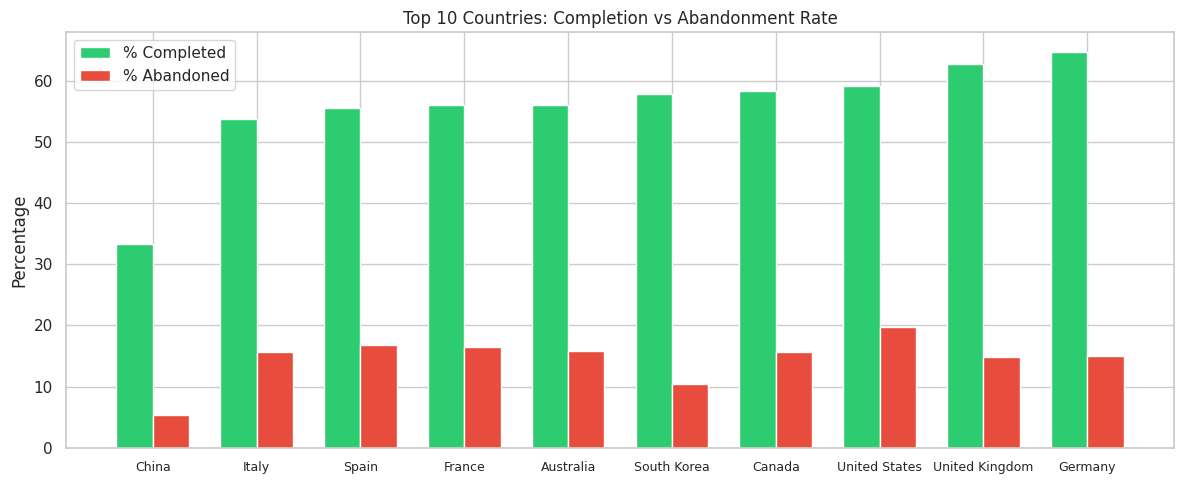

,country,total,completed,abandoned,c_pct,a_pct
0,United States,56724,33524.0,11228.0,59.1,19.8
1,China,19201,6403.0,1013.0,33.3,5.3
2,Canada,10977,6415.0,1724.0,58.4,15.7
3,Germany,10754,6963.0,1615.0,64.7,15.0
4,France,10492,5889.0,1732.0,56.1,16.5
5,United Kingdom,10422,6543.0,1553.0,62.8,14.9
6,Spain,10000,5561.0,1677.0,55.6,16.8
7,Italy,8284,4459.0,1301.0,53.8,15.7
8,South Korea,8216,4759.0,853.0,57.9,10.4
9,Australia,6730,3777.0,1063.0,56.1,15.8


In [9]:
df_country = con.execute("""
    SELECT c.country_name AS country, COUNT(*) AS total,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS c_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS a_pct
    FROM main.brg_trial_country bc
    JOIN main.dim_country c ON bc.country_id = c.country_id
    JOIN main.fct_clinical_trials f ON bc.nct_id = f.nct_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    GROUP BY c.country_name ORDER BY total DESC LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
ct = df_country.sort_values('c_pct', ascending=True)
x = range(len(ct))
w = 0.35
ax.bar([i - w/2 for i in x], ct['c_pct'], w, color='#2ecc71', label='% Completed')
ax.bar([i + w/2 for i in x], ct['a_pct'], w, color='#e74c3c', label='% Abandoned')
ax.set_xticks(x)
ax.set_xticklabels(ct['country'], fontsize=9)
ax.set_title('Top 10 Countries: Completion vs Abandonment Rate')
ax.set_ylabel('Percentage')
ax.legend()
plt.tight_layout()
fig.savefig(CHARTS / "07_completion_by_country.png", dpi=150, bbox_inches='tight')
plt.show()
df_country

## Tie-out Summary

Compare each section's DuckDB numbers against the Power BI dashboard. Mark discrepancies.

In [10]:
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.
